# Top 5 main assumptions of LinearRegression:

## The algorithm never tells if it is wrong or not this is the biggest problem
If you feed data into `LinearRegression()`, it will calculate the math and spit out a line, even if that line is completely illogical. To prevent your model from lying to you, statisticians created the 5 Assumptions of Linear Regression. If your data breaks these rules, your $R^2$ score is useless, and your predictions are unsafe.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# 1. Generate some dummy data for demonstration
np.random.seed(42)
X1 = np.random.uniform(1, 10, 500)
X2 = X1 * 0.8 + np.random.normal(0, 0.5, 500) # Correlated with X1
X3 = np.random.uniform(1, 10, 500) # Uncorrelated
# We purposefully add a slight curve to violate linearity, and expanding noise to violate homoscedasticity!
y = (X1 ** 1.5) + np.random.normal(0, X1 * 0.5, 500)

df = pd.DataFrame({'Feature1': X1, 'Feature2': X2, 'Feature3': X3, 'Target': y})

# 2. Train the Model
model = LinearRegression()
X_features = df[['Feature1', 'Feature2', 'Feature3']] # Use multiple features for multicollinearity
model.fit(X_features, df['Target'])
predictions = model.predict(X_features)

# 3. Calculate the Residuals (Mistakes)
residuals = df['Target'] - predictions

### 1. Linearity (The Golden Rule)
**The Theory:** Linear Regression only works if the relationship between your features ($X$) and your target ($y$) is actually a straight line. If the true relationship is a curve (like exponential growth), fitting a straight line through it is mathematically invalid.

**The Visualization (True vs. Predicted Plot):**
*   **Assumption Met:** If you plot your actual data against your predicted data, the points should form a tight, straight diagonal band.
*   **Assumption Violated:** The points will form a clear "U" or "bow" shape, proving the model is trying to force a straight ruler onto curved data.

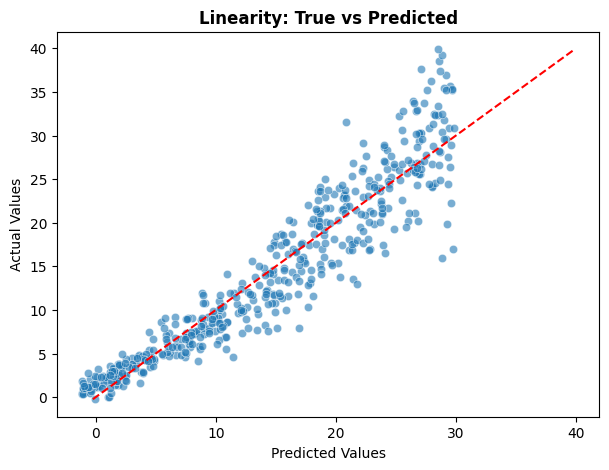

In [2]:
# Plot for Linearity (True vs Predicted)
plt.figure(figsize=(7, 5))
sns.scatterplot(x=predictions, y=df['Target'], alpha=0.6)
plt.plot([df['Target'].min(), df['Target'].max()], [df['Target'].min(), df['Target'].max()], color='red', linestyle='--')
plt.title('Linearity: True vs Predicted', fontweight='bold')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

### 2. No Multicollinearity (The Independence Rule)
**The Theory:** Your features must be independent of each other. If you are predicting Placement LPA, having CGPA and Coding_Score is great. But if you have CGPA and Percentage_Marks, those two features are almost identical. They will confuse the math, causing the algorithm to wildly swing the weights ($b_1$, $b_2$) because it doesn't know which identical feature to credit for the prediction.

**The Visualization (Correlation Heatmap):**
*   **Assumption Met:** A heatmap shows low correlation scores (close to 0) between all your features.
*   **Assumption Violated:** The heatmap shows dark red squares (correlation $> 0.8$) between two features, signaling you need to delete one of them.

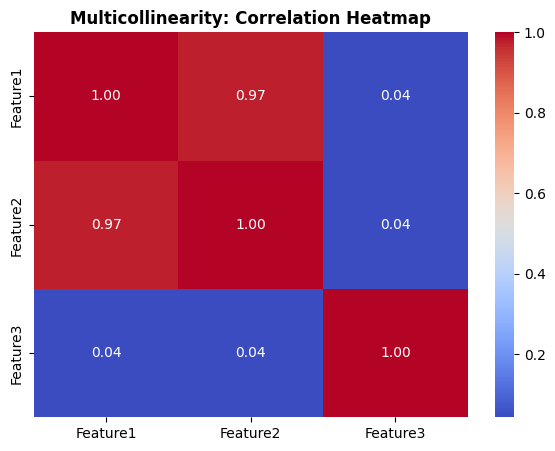

In [3]:
# Plot for Multicollinearity (Correlation Heatmap)
plt.figure(figsize=(7, 5))
correlation_matrix = df[['Feature1', 'Feature2', 'Feature3']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Multicollinearity: Correlation Heatmap', fontweight='bold')
plt.show()

### 3. Normality of Residuals (The Symmetrical Mistake Rule)
**The Theory:** Your model is going to make mistakes (residuals). That is fine. But those mistakes must form a normal distribution (a bell curve) centered around zero. It means your model should make small mistakes frequently, and massive mistakes rarely. It should also over-predict just as often as it under-predicts.

**The Visualization (Residual Histogram):**
*   **Assumption Met:** A perfect, symmetrical bell curve centered exactly at $0$.
*   **Assumption Violated:** The histogram is heavily skewed to one side, meaning your model has a severe bias and is consistently predicting too high or too low.

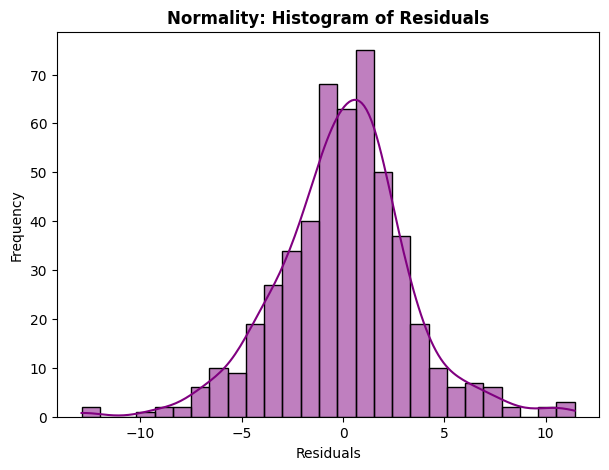

In [4]:
# Plot for Normality of Residuals (Histogram)
plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Normality: Histogram of Residuals', fontweight='bold')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

### 4. Homoscedasticity (The Constant Variance Rule)
**The Theory:** "Homo" means same, "scedasticity" means scatter. The size of your model's mistakes should be roughly the same across the entire dataset. If your model is highly accurate at predicting salaries for junior developers but completely falls apart and makes massive errors when predicting salaries for senior developers, your variance is not constant.

**The Visualization (Residuals vs. Predicted Plot):**
*   **Assumption Met:** The points look like a completely random, uniform cloud of static.
*   **Assumption Violated:** The points form a clear "Cone" or "Funnel" shape that starts tight and gets wider as the predictions get larger.

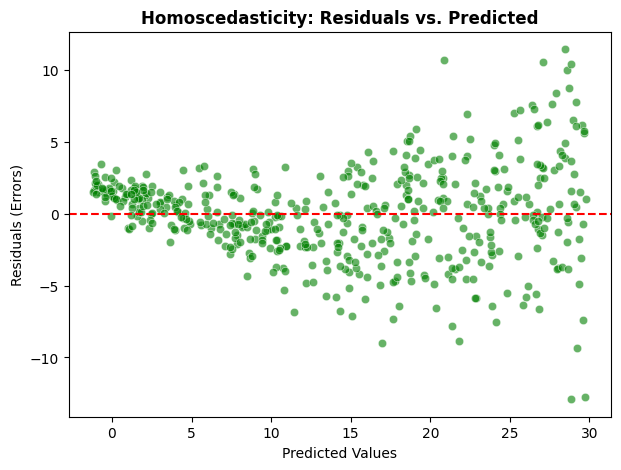

In [5]:
# Plot for Homoscedasticity (Residuals vs Predicted)
plt.figure(figsize=(7, 5))
sns.scatterplot(x=predictions, y=residuals, alpha=0.6, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('Homoscedasticity: Residuals vs. Predicted', fontweight='bold')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.show()

### 5. No Autocorrelation of Errors (The Memoryless Rule)
**The Theory:** Your model's mistakes should not follow a hidden pattern. If it makes a mistake on Row 5, that mistake should not predict the mistake on Row 6. This usually happens in Time-Series data (e.g., predicting stock prices), where a bad prediction on Monday leaks into Tuesday.

**The Visualization (Residuals vs. Index/Time Plot):**
*   **Assumption Met:** The errors jump up and down randomly with absolutely no identifiable pattern.
*   **Assumption Violated:** The errors form a distinct tracking pattern, like a sine wave or a stock market chart, proving the rows are secretly connected.

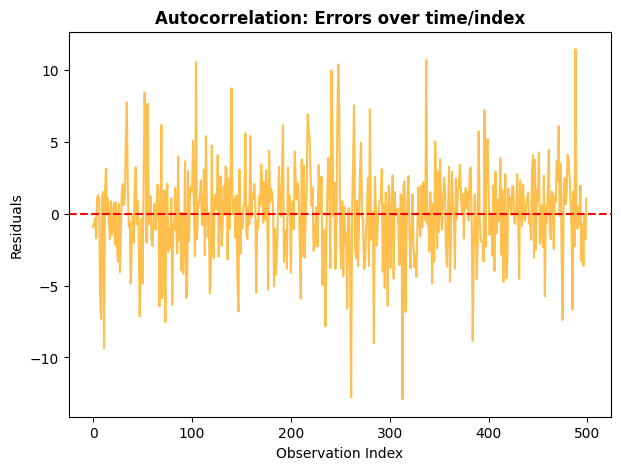

In [6]:
# Plot for Autocorrelation (Residuals vs Row Index)
plt.figure(figsize=(7, 5))
sns.lineplot(x=range(len(residuals)), y=residuals, color='orange', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Autocorrelation: Errors over time/index', fontweight='bold')
plt.xlabel('Observation Index')
plt.ylabel('Residuals')
plt.show()